# Credit Risk Analysis — Modelo Predictivo
## Objetivo
Entrenar un modelo de regresión logística para predecir la probabilidad 
de morosidad grave en clientes bancarios y evaluar su desempeño con 
métricas apropiadas para datos desbalanceados.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Cargar datos procesados
X_train = np.load('../data/X_train_balanced.npy')
X_test = np.load('../data/X_test_scaled.npy')
y_train = np.load('../data/y_train_balanced.npy')
y_test = np.load('../data/y_test.npy')

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (223876, 8)
X_test: (29998, 8)


In [2]:
modelo = LogisticRegression(random_state=42, max_iter=1000)
modelo.fit(X_train,y_train )

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [3]:
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     28023
           1       0.12      0.63      0.21      1975

    accuracy                           0.68     29998
   macro avg       0.54      0.66      0.50     29998
weighted avg       0.91      0.68      0.76     29998



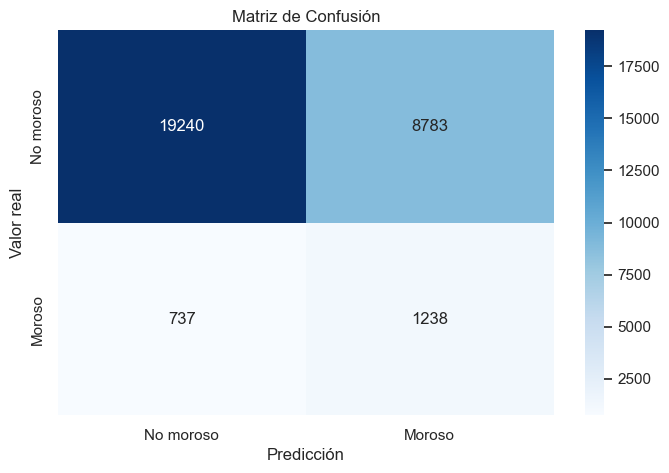

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No moroso', 'Moroso'],
            yticklabels=['No moroso', 'Moroso'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [5]:
y_prob = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {auc:.4f}')

ROC-AUC Score: 0.7289


## Resultados del Modelo — Regresión Logística

| Métrica | Valor |
|---------|-------|
| ROC-AUC | 0.7289 |
| Recall (morosos) | 0.63 |
| Precision (morosos) | 0.12 |
| F1-Score (morosos) | 0.21 |
| Accuracy general | 0.68 |

## Interpretación
- El modelo detecta 63 de cada 100 morosos reales (recall).
- ROC-AUC de 0.73 indica capacidad moderada de discriminación.
- Los 737 falsos negativos representan el riesgo crediticio no detectado.
- La accuracy de 68% no es la métrica correcta por el desbalance de clases.

## Limitaciones
- Regresión logística es el modelo base — modelos como Random Forest 
  o XGBoost podrían mejorar significativamente el AUC.
- El umbral de clasificación (0.5) puede ajustarse según la 
  tolerancia al riesgo del banco.